# Alberta Postsecondary Enrolment — Combined Analysis

## Objective

This analysis combines institutional enrolment trends with student-status
data to examine how Alberta's postsecondary enrolment changed between
2014/15 and 2023/24.

The analysis focuses on three questions:

1. How much did Alberta's postsecondary enrolment change?
2. Which institutions contributed most to that change?
3. To what extent was institutional growth associated with changes in
   Canadian and international student enrolment?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

In [3]:
dataset1 = pd.read_csv("../data/processed/alberta_enrolment_2014_2024_clean.csv")

dataset2 = pd.read_csv("../data/processed/alberta_student_status_clean.csv")

In [4]:
print("Dataset 1 shape:", dataset1.shape)
print("Dataset 2 shape:", dataset2.shape)

Dataset 1 shape: (260, 7)
Dataset 2 shape: (780, 10)


In [5]:
print("DATASET 1 COLUMNS")
print(dataset1.columns.tolist())

print("\nDATASET 2 COLUMNS")
print(dataset2.columns.tolist())

DATASET 1 COLUMNS
['Province', 'Institution', 'Record_Type', 'Academic_Year', 'Academic_Year_Start', 'Academic_Year_End', 'Enrolment']

DATASET 2 COLUMNS
['Institution_Raw', 'Institution', 'Institution_Standardized', 'Academic_Year', 'Enrolment', 'Student_Status', 'Province', 'Record_Type', 'Academic_Year_Start', 'Academic_Year_End']


In [6]:
dataset1.shape
dataset2.shape

(780, 10)

In [7]:
dataset1.shape

(260, 7)

In [8]:
dataset1.columns.tolist()

['Province',
 'Institution',
 'Record_Type',
 'Academic_Year',
 'Academic_Year_Start',
 'Academic_Year_End',
 'Enrolment']

In [9]:
dataset2.columns.tolist()

['Institution_Raw',
 'Institution',
 'Institution_Standardized',
 'Academic_Year',
 'Enrolment',
 'Student_Status',
 'Province',
 'Record_Type',
 'Academic_Year_Start',
 'Academic_Year_End']

In [10]:
print("DATASET 1 RECORD TYPES")
print(dataset1["Record_Type"].value_counts())

print("\nDATASET 2 RECORD TYPES")
print(dataset2["Record_Type"].value_counts())

print("\nDATASET 1 PROVINCES")
print(dataset1["Province"].value_counts())

print("\nDATASET 2 PROVINCES")
print(dataset2["Province"].value_counts())

DATASET 1 RECORD TYPES
Record_Type
Institution       250
Province Total     10
Name: count, dtype: int64

DATASET 2 RECORD TYPES
Record_Type
Institution       750
Province Total     30
Name: count, dtype: int64

DATASET 1 PROVINCES
Province
Alberta    260
Name: count, dtype: int64

DATASET 2 PROVINCES
Province
Alberta    780
Name: count, dtype: int64


In [11]:
print(
    "Dataset 1 duplicate institution-year records:",
    dataset1.duplicated(
        subset=["Institution", "Academic_Year"]
    ).sum()
)

print(
    "Dataset 2 duplicate institution-year-status records:",
    dataset2.duplicated(
        subset=[
            "Institution_Standardized",
            "Academic_Year",
            "Student_Status"
        ]
    ).sum()
)

Dataset 1 duplicate institution-year records: 0
Dataset 2 duplicate institution-year-status records: 0


In [12]:
status_wide = (
    dataset2
    .pivot(
        index=[
            "Institution_Standardized",
            "Academic_Year"
        ],
        columns="Student_Status",
        values="Enrolment"
    )
    .reset_index()
)

status_wide.head()

Student_Status,Institution_Standardized,Academic_Year,Canadian,International,Total
0,Alberta,2014/2015,"167,463.00","16,458.00","184,026.00"
1,Alberta,2015/2016,"167,946.00","17,478.00","185,679.00"
2,Alberta,2016/2017,"172,506.00","18,303.00","190,947.00"
3,Alberta,2017/2018,"175,065.00","18,798.00","194,010.00"
4,Alberta,2018/2019,"178,617.00","21,663.00","200,391.00"


In [13]:
status_wide.shape

(260, 5)

In [14]:
status_wide.columns.tolist()

['Institution_Standardized',
 'Academic_Year',
 'Canadian',
 'International',
 'Total']

In [15]:
institutions_1 = set(dataset1["Institution"].unique())
institutions_2 = set(status_wide["Institution_Standardized"].unique())

print("Institutions in Dataset 1:", len(institutions_1))
print("Institutions in Dataset 2:", len(institutions_2))

print("\nOnly in Dataset 1:")
print(sorted(institutions_1 - institutions_2))

print("\nOnly in Dataset 2:")
print(sorted(institutions_2 - institutions_1))

Institutions in Dataset 1: 26
Institutions in Dataset 2: 26

Only in Dataset 1:
[]

Only in Dataset 2:
[]


In [16]:
combined = dataset1.merge(
    status_wide,
    left_on=["Institution", "Academic_Year"],
    right_on=["Institution_Standardized", "Academic_Year"],
    how="left",
    validate="one_to_one"
)

combined.shape

(260, 11)

In [17]:
validate="one_to_one"

In [18]:
combined.head()

,Province,Institution,Record_Type,Academic_Year,Academic_Year_Start,Academic_Year_End,Enrolment,Institution_Standardized,Canadian,International,Total
0,Alberta,Alberta,Province Total,2014/2015,2014,2015,184026,Alberta,"167,463.00","16,458.00","184,026.00"
1,Alberta,Alberta,Province Total,2015/2016,2015,2016,185679,Alberta,"167,946.00","17,478.00","185,679.00"
2,Alberta,Alberta,Province Total,2016/2017,2016,2017,190947,Alberta,"172,506.00","18,303.00","190,947.00"
3,Alberta,Alberta,Province Total,2017/2018,2017,2018,194010,Alberta,"175,065.00","18,798.00","194,010.00"
4,Alberta,Alberta,Province Total,2018/2019,2018,2019,200391,Alberta,"178,617.00","21,663.00","200,391.00"


In [19]:
combined.columns.tolist()

['Province',
 'Institution',
 'Record_Type',
 'Academic_Year',
 'Academic_Year_Start',
 'Academic_Year_End',
 'Enrolment',
 'Institution_Standardized',
 'Canadian',
 'International',
 'Total']

In [20]:
combined[
    combined["Institution_Standardized"].isna()
]

,Province,Institution,Record_Type,Academic_Year,Academic_Year_Start,Academic_Year_End,Enrolment,Institution_Standardized,Canadian,International,Total


In [21]:
print(
    "Unmatched records:",
    combined["Institution_Standardized"].isna().sum()
)

print(
    "Combined dataset shape:",
    combined.shape
)

Unmatched records: 0
Combined dataset shape: (260, 11)


In [22]:
combined["Total_Difference"] = (
    combined["Enrolment"] - combined["Total"]
)

combined["Total_Difference_Pct"] = (
    combined["Total_Difference"].abs()
    / combined["Enrolment"]
    * 100
)

print(
    "Exact matches:",
    (combined["Total_Difference"] == 0).sum()
)

print(
    "Within ±3 students:",
    (combined["Total_Difference"].abs() <= 3).sum()
)

print(
    "Within ±10 students:",
    (combined["Total_Difference"].abs() <= 10).sum()
)

print(
    "Largest absolute difference:",
    combined["Total_Difference"].abs().max()
)

print(
    "Mean percentage difference:",
    combined["Total_Difference_Pct"].mean()
)

Exact matches: 260
Within ±3 students: 260
Within ±10 students: 260
Largest absolute difference: 0.0
Mean percentage difference: 0.0


In [23]:
combined[
    [
        "Institution",
        "Academic_Year",
        "Enrolment",
        "Total",
        "Total_Difference",
        "Total_Difference_Pct"
    ]
].sort_values(
    "Total_Difference_Pct",
    ascending=False
).head(15).round(2)

,Institution,Academic_Year,Enrolment,Total,Total_Difference,Total_Difference_Pct
0,Alberta,2014/2015,184026,"184,026.00",0.00,0.00
1,Alberta,2015/2016,185679,"185,679.00",0.00,0.00
2,Alberta,2016/2017,190947,"190,947.00",0.00,0.00
3,Alberta,2017/2018,194010,"194,010.00",0.00,0.00
4,Alberta,2018/2019,200391,"200,391.00",0.00,0.00
5,Alberta,2019/2020,203823,"203,823.00",0.00,0.00
6,Alberta,2020/2021,203523,"203,523.00",0.00,0.00
7,Alberta,2021/2022,203580,"203,580.00",0.00,0.00
8,Alberta,2022/2023,205734,"205,734.00",0.00,0.00
9,Alberta,2023/2024,216957,"216,957.00",0.00,0.00


In [24]:
combined_clean = combined.drop(
    columns=[
        "Institution_Standardized",
        "Total",
        "Total_Difference",
        "Total_Difference_Pct"
    ]
).copy()

combined_clean.columns.tolist()

['Province',
 'Institution',
 'Record_Type',
 'Academic_Year',
 'Academic_Year_Start',
 'Academic_Year_End',
 'Enrolment',
 'Canadian',
 'International']

In [25]:
combined_clean.shape

(260, 9)

In [26]:
combined_clean["International_Share_Pct"] = (
    combined_clean["International"]
    / combined_clean["Enrolment"]
    * 100
)

combined_clean["Canadian_Share_Pct"] = (
    combined_clean["Canadian"]
    / combined_clean["Enrolment"]
    * 100
)

combined_clean["Status_Sum_Difference"] = (
    combined_clean["Enrolment"]
    - (
        combined_clean["Canadian"]
        + combined_clean["International"]
    )
)

In [27]:
combined_clean.head().round(2)

,Province,Institution,Record_Type,Academic_Year,Academic_Year_Start,Academic_Year_End,Enrolment,Canadian,International,International_Share_Pct,Canadian_Share_Pct,Status_Sum_Difference
0,Alberta,Alberta,Province Total,2014/2015,2014,2015,184026,"167,463.00","16,458.00",8.94,91.00,105.00
1,Alberta,Alberta,Province Total,2015/2016,2015,2016,185679,"167,946.00","17,478.00",9.41,90.45,255.00
2,Alberta,Alberta,Province Total,2016/2017,2016,2017,190947,"172,506.00","18,303.00",9.59,90.34,138.00
3,Alberta,Alberta,Province Total,2017/2018,2017,2018,194010,"175,065.00","18,798.00",9.69,90.24,147.00
4,Alberta,Alberta,Province Total,2018/2019,2018,2019,200391,"178,617.00","21,663.00",10.81,89.13,111.00


In [28]:
combined_clean.shape

(260, 12)

In [29]:
print("FINAL COMBINED DATASET")

print("\nRows:", len(combined_clean))
print("Columns:", len(combined_clean.columns))

print(
    "Institutions/geographies:",
    combined_clean["Institution"].nunique()
)

print(
    "Academic years:",
    combined_clean["Academic_Year"].nunique()
)

print(
    "Missing values:",
    combined_clean.isna().sum().sum()
)

print(
    "Duplicate institution-year records:",
    combined_clean.duplicated(
        subset=["Institution", "Academic_Year"]
    ).sum()
)

print(
    "Negative enrolment values:",
    (
        combined_clean[
            ["Enrolment", "Canadian", "International"]
        ] < 0
    ).sum().sum()
)

print(
    "\nMaximum absolute status reconciliation difference:",
    combined_clean["Status_Sum_Difference"].abs().max()
)

print(
    "Mean absolute status reconciliation difference:",
    combined_clean["Status_Sum_Difference"].abs().mean()
)

FINAL COMBINED DATASET

Rows: 260
Columns: 12
Institutions/geographies: 26
Academic years: 10
Missing values: 0
Duplicate institution-year records: 0
Negative enrolment values: 0

Maximum absolute status reconciliation difference: 255.0
Mean absolute status reconciliation difference: 7.3961538461538465


In [30]:
provincial = combined_clean[
    combined_clean["Record_Type"] == "Province Total"
].copy()

institutions = combined_clean[
    combined_clean["Record_Type"] == "Institution"
].copy()

print("Provincial records:", provincial.shape)
print("Institution records:", institutions.shape)

print(
    "\nNumber of institutions:",
    institutions["Institution"].nunique()
)

Provincial records: (10, 12)
Institution records: (250, 12)

Number of institutions: 25


In [31]:
combined_clean.to_csv(
    "../data/processed/alberta_postsecondary_master.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


# Combined Institutional Analysis

This section examines how enrolment growth varied across Alberta postsecondary
institutions between 2014/15 and 2023/24 and evaluates the relative contribution
of Canadian and international students to institutional growth.

In [32]:
institutions

,Province,Institution,Record_Type,Academic_Year,Academic_Year_Start,Academic_Year_End,Enrolment,Canadian,International,International_Share_Pct,Canadian_Share_Pct,Status_Sum_Difference
10,Alberta,Alberta University of the Arts,Institution,2014/2015,2014,2015,1116,"1,047.00",63.00,5.65,93.82,6.00
11,Alberta,Alberta University of the Arts,Institution,2015/2016,2015,2016,1158,"1,083.00",69.00,5.96,93.52,6.00
12,Alberta,Alberta University of the Arts,Institution,2016/2017,2016,2017,1140,"1,068.00",66.00,5.79,93.68,6.00
13,Alberta,Alberta University of the Arts,Institution,2017/2018,2017,2018,1107,"1,026.00",81.00,7.32,92.68,0.00
14,Alberta,Alberta University of the Arts,Institution,2018/2019,2018,2019,1077,993.00,87.00,8.08,92.20,-3.00
...,...,...,...,...,...,...,...,...,...,...,...,...
255,Alberta,University of Lethbridge,Institution,2019/2020,2019,2020,8949,"8,391.00",561.00,6.27,93.76,-3.00
256,Alberta,University of Lethbridge,Institution,2020/2021,2020,2021,8829,"8,319.00",510.00,5.78,94.22,0.00
257,Alberta,University of Lethbridge,Institution,2021/2022,2021,2022,9117,"8,499.00",618.00,6.78,93.22,0.00
258,Alberta,University of Lethbridge,Institution,2022/2023,2022,2023,8553,"7,722.00",831.00,9.72,90.28,0.00


In [33]:
start_year = institutions[
    institutions["Academic_Year"] == "2014/2015"
][
    ["Institution", "Enrolment", "Canadian", "International"]
].copy()

end_year = institutions[
    institutions["Academic_Year"] == "2023/2024"
][
    ["Institution", "Enrolment", "Canadian", "International"]
].copy()


institution_change = start_year.merge(
    end_year,
    on="Institution",
    suffixes=("_2014_15", "_2023_24"),
    validate="one_to_one"
)

institution_change.shape

(25, 7)

In [34]:
institution_change["Total_Change"] = (
    institution_change["Enrolment_2023_24"]
    - institution_change["Enrolment_2014_15"]
)

institution_change["Canadian_Change"] = (
    institution_change["Canadian_2023_24"]
    - institution_change["Canadian_2014_15"]
)

institution_change["International_Change"] = (
    institution_change["International_2023_24"]
    - institution_change["International_2014_15"]
)

institution_change["Total_Growth_Pct"] = (
    institution_change["Total_Change"]
    / institution_change["Enrolment_2014_15"]
    * 100
)

institution_change[
    [
        "Institution",
        "Enrolment_2014_15",
        "Enrolment_2023_24",
        "Total_Change",
        "Total_Growth_Pct",
        "Canadian_Change",
        "International_Change"
    ]
].sort_values(
    "Total_Change",
    ascending=False
).round(2)

,Institution,Enrolment_2014_15,Enrolment_2023_24,Total_Change,Total_Growth_Pct,Canadian_Change,International_Change
23,University of Calgary,31308,38715,7407,23.66,"3,402.00","4,002.00"
22,University of Alberta,38520,45306,6786,17.62,"5,283.00","1,500.00"
12,NorQuest College,4212,10299,6087,144.52,"2,541.00","3,546.00"
11,Mount Royal University,12372,14709,2337,18.89,"2,274.00",120.00
13,Northern Alberta Institute of Technology,10833,12993,2160,19.94,930.00,"1,245.00"
3,Bow Valley College,6891,8931,2040,29.60,-177.00,"2,214.00"
5,Concordia University of Edmonton,1506,2568,1062,70.52,708.00,357.00
19,Southern Alberta Institute of Technology,14307,15306,999,6.98,"-2,781.00","3,789.00"
18,Red Deer Polytechnic,3345,4242,897,26.82,186.00,714.00
16,Olds College,1371,2223,852,62.14,468.00,384.00


In [35]:
#Trying to find the answer for - Which institutions actually drove Alberta's postsecondary enrolment growth, 
#and was their growth Canadian or international?

In [36]:
prov_start = provincial.loc[
    provincial["Academic_Year"] == "2014/2015",
    "Enrolment"
].iloc[0]

prov_end = provincial.loc[
    provincial["Academic_Year"] == "2023/2024",
    "Enrolment"
].iloc[0]

provincial_total_growth = prov_end - prov_start

print(f"Alberta enrolment in 2014/15: {prov_start:,.0f}")
print(f"Alberta enrolment in 2023/24: {prov_end:,.0f}")
print(f"Alberta net enrolment growth: {provincial_total_growth:,.0f}")

Alberta enrolment in 2014/15: 184,026
Alberta enrolment in 2023/24: 216,957
Alberta net enrolment growth: 32,931


In [37]:
institution_change["Contribution_to_Provincial_Growth_Pct"] = (
    institution_change["Total_Change"]
    / provincial_total_growth
    * 100
)

In [38]:
institution_change[
    [
        "Institution",
        "Total_Change",
        "Total_Growth_Pct",
        "Contribution_to_Provincial_Growth_Pct"
    ]
].sort_values(
    "Total_Change",
    ascending=False
).head(10).round(2)

,Institution,Total_Change,Total_Growth_Pct,Contribution_to_Provincial_Growth_Pct
23,University of Calgary,7407,23.66,22.49
22,University of Alberta,6786,17.62,20.61
12,NorQuest College,6087,144.52,18.48
11,Mount Royal University,2337,18.89,7.10
13,Northern Alberta Institute of Technology,2160,19.94,6.56
3,Bow Valley College,2040,29.60,6.19
5,Concordia University of Edmonton,1062,70.52,3.22
19,Southern Alberta Institute of Technology,999,6.98,3.03
18,Red Deer Polytechnic,897,26.82,2.72
16,Olds College,852,62.14,2.59


In [42]:
def classify_growth(row):

    total = row["Total_Change"]
    canadian = row["Canadian_Change"]
    international = row["International_Change"]

    if total > 0:

        if canadian > 0 and international > 0:
            return "Growth from Both"

        elif canadian <= 0 and international > 0:
            return "International-Led Growth"

        elif canadian > 0 and international <= 0:
            return "Canadian-Led Growth"

        else:
            return "Other Growth"

    elif total < 0:

        if canadian < 0 and international > 0:
            return "Decline Despite International Growth"

        elif canadian > 0 and international < 0:
            return "Decline Despite Canadian Growth"

        elif canadian < 0 and international <= 0:
            return "Decline in Both"

        else:
            return "Other Decline"

    else:
        return "No Net Change"


institution_change["Growth_Type_Detailed"] = (
    institution_change.apply(
        classify_growth,
        axis=1
    )
)

institution_change["Growth_Type_Detailed"].value_counts()

Growth_Type_Detailed
Growth from Both                        13
International-Led Growth                 5
Decline Despite International Growth     4
Canadian-Led Growth                      3
Name: count, dtype: int64

In [43]:
institution_change[
    [
        "Institution",
        "Total_Change",
        "Canadian_Change",
        "International_Change",
        "Growth_Type_Detailed"
    ]
].sort_values("Total_Change")

,Institution,Total_Change,Canadian_Change,International_Change,Growth_Type_Detailed
2,Athabasca University,-1572,"-1,725.00",162.00,Decline Despite International Growth
4,Burman University,-141,-162.00,21.00,Decline Despite International Growth
15,Northwestern Polytechnic,-87,-354.00,261.00,Decline Despite International Growth
10,Medicine Hat College,-3,-126.00,123.00,Decline Despite International Growth
1,Ambrose University,33,9.00,21.00,Growth from Both
0,Alberta University of the Arts,84,54.00,36.00,Growth from Both
21,The King's University,102,51.00,57.00,Growth from Both
20,St. Mary's University,192,192.00,-3.00,Canadian-Led Growth
6,Grant MacEwan University,231,474.00,-243.00,Canadian-Led Growth
7,Keyano College,375,-306.00,684.00,International-Led Growth


## Drivers of Institutional Enrolment Change

The following visualization compares changes in Canadian and international
enrolment between 2014/15 and 2023/24. This helps distinguish institutions
whose growth was broad-based from those where international enrolment offset
declines in Canadian enrolment.

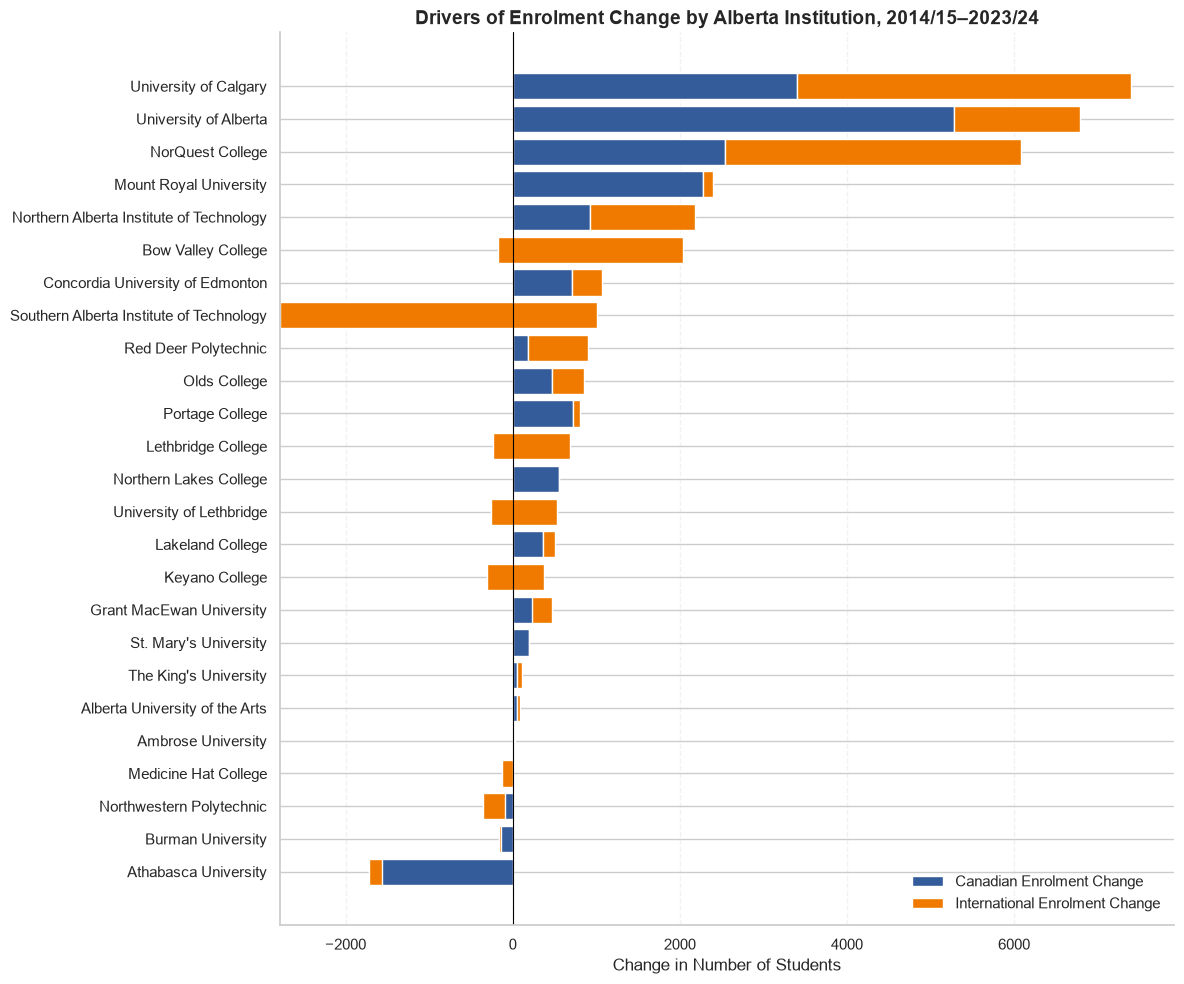

In [44]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = (
    institution_change
    .sort_values("Total_Change", ascending=True)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 10))

y = np.arange(len(plot_data))

ax.barh(
    y,
    plot_data["Canadian_Change"],
    color="#355C9A",
    label="Canadian Enrolment Change"
)

ax.barh(
    y,
    plot_data["International_Change"],
    left=plot_data["Canadian_Change"],
    color="#F07A00",
    label="International Enrolment Change"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_data["Institution"])

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_title(
    "Drivers of Enrolment Change by Alberta Institution, 2014/15–2023/24",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Change in Number of Students")

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
# trying to find: Which institutions actually drove Alberta's overall postsecondary enrolment growth?

## Institutional Contribution to Alberta's Enrolment Growth

Although most Alberta institutions experienced enrolment growth between
2014/15 and 2023/24, that growth was not evenly distributed.

The following analysis measures how much each institution contributed to
Alberta's overall net increase in postsecondary enrolment.

In [46]:
prov_start = provincial[
    provincial["Academic_Year"] == "2014/2015"
]["Enrolment"].iloc[0]

prov_end = provincial[
    provincial["Academic_Year"] == "2023/2024"
]["Enrolment"].iloc[0]

prov_growth = prov_end - prov_start

print(f"Alberta enrolment in 2014/15: {prov_start:,.0f}")
print(f"Alberta enrolment in 2023/24: {prov_end:,.0f}")
print(f"Net provincial growth: {prov_growth:,.0f}")
print(f"Provincial growth rate: {(prov_growth / prov_start) * 100:.2f}%")

Alberta enrolment in 2014/15: 184,026
Alberta enrolment in 2023/24: 216,957
Net provincial growth: 32,931
Provincial growth rate: 17.89%


In [47]:
institution_change["Contribution_to_Provincial_Growth_Pct"] = (
    institution_change["Total_Change"]
    / prov_growth
    * 100
)

contribution = (
    institution_change[
        [
            "Institution",
            "Total_Change",
            "Contribution_to_Provincial_Growth_Pct"
        ]
    ]
    .sort_values(
        "Contribution_to_Provincial_Growth_Pct",
        ascending=False
    )
)

contribution.head(10).round(2)

,Institution,Total_Change,Contribution_to_Provincial_Growth_Pct
23,University of Calgary,7407,22.49
22,University of Alberta,6786,20.61
12,NorQuest College,6087,18.48
11,Mount Royal University,2337,7.10
13,Northern Alberta Institute of Technology,2160,6.56
3,Bow Valley College,2040,6.19
5,Concordia University of Edmonton,1062,3.22
19,Southern Alberta Institute of Technology,999,3.03
18,Red Deer Polytechnic,897,2.72
16,Olds College,852,2.59


In [48]:
top3_growth = contribution.head(3)["Total_Change"].sum()
top5_growth = contribution.head(5)["Total_Change"].sum()
top10_growth = contribution.head(10)["Total_Change"].sum()

print(
    f"Top 3 institutions contributed "
    f"{top3_growth / prov_growth * 100:.2f}% "
    f"of Alberta's net enrolment growth."
)

print(
    f"Top 5 institutions contributed "
    f"{top5_growth / prov_growth * 100:.2f}% "
    f"of Alberta's net enrolment growth."
)

print(
    f"Top 10 institutions contributed "
    f"{top10_growth / prov_growth * 100:.2f}% "
    f"of Alberta's net enrolment growth."
)

Top 3 institutions contributed 61.58% of Alberta's net enrolment growth.
Top 5 institutions contributed 75.24% of Alberta's net enrolment growth.
Top 10 institutions contributed 93.00% of Alberta's net enrolment growth.


In [49]:
# Top 3 uni: University of Calgary + University of Alberta + NorQuest College

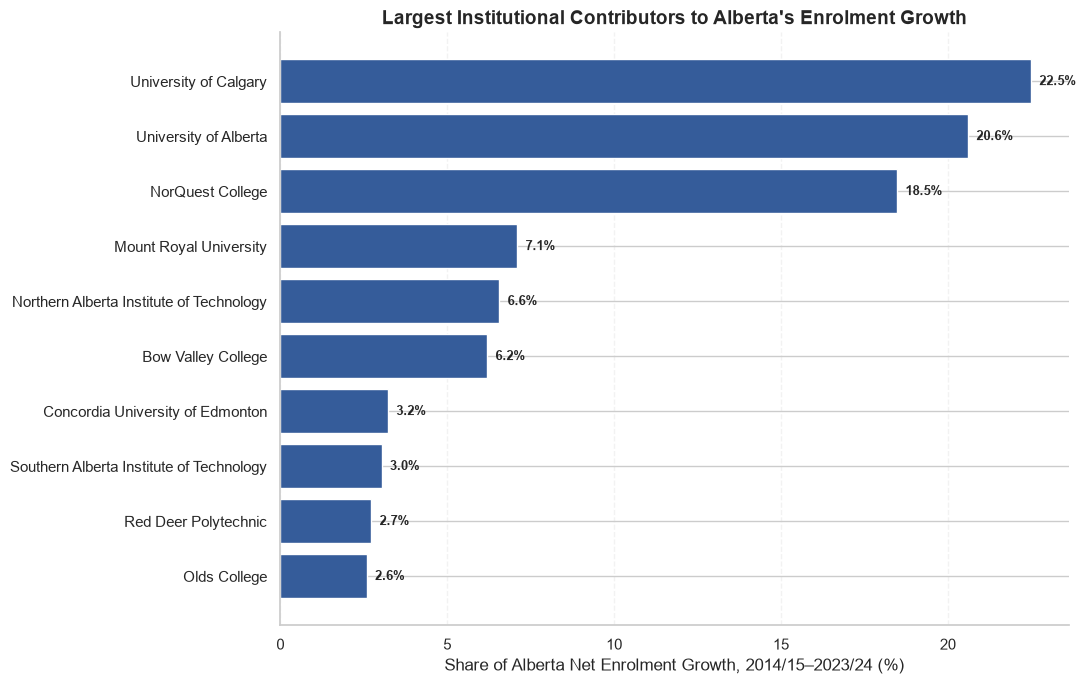

In [50]:
top_contributors = (
    contribution
    .head(10)
    .sort_values(
        "Contribution_to_Provincial_Growth_Pct",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_contributors["Institution"],
    top_contributors["Contribution_to_Provincial_Growth_Pct"],
    color="#355C9A"
)

ax.set_title(
    "Largest Institutional Contributors to Alberta's Enrolment Growth",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Share of Alberta Net Enrolment Growth, 2014/15–2023/24 (%)"
)

ax.set_ylabel("")

for bar, value in zip(
    bars,
    top_contributors["Contribution_to_Provincial_Growth_Pct"]
):
    ax.text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

Alberta's postsecondary enrolment growth was concentrated among a relatively
small number of institutions. The University of Calgary, University of Alberta,
and NorQuest College were the three largest contributors to provincial net
enrolment growth.

The results also show that institutional growth followed different patterns.
While some major contributors expanded both Canadian and international
enrolment, other institutions relied substantially on international enrolment
growth to offset declines in Canadian students.

# Final Summary and Power BI Preparation

In [53]:
## 1. Final Project KPIs

In [54]:
final_kpis = {
    "Enrolment_2014_15": prov_start,
    "Enrolment_2023_24": prov_end,
    "Net_Growth": prov_growth,
    "Growth_Rate_Pct": (prov_growth / prov_start) * 100,
    "Top3_Growth_Contribution_Pct": top3_growth / prov_growth * 100,
    "Top5_Growth_Contribution_Pct": top5_growth / prov_growth * 100,
    "Top10_Growth_Contribution_Pct": top10_growth / prov_growth * 100
}

for metric, value in final_kpis.items():
    print(f"{metric}: {value:,.2f}")

Enrolment_2014_15: 184,026.00
Enrolment_2023_24: 216,957.00
Net_Growth: 32,931.00
Growth_Rate_Pct: 17.89
Top3_Growth_Contribution_Pct: 61.58
Top5_Growth_Contribution_Pct: 75.24
Top10_Growth_Contribution_Pct: 93.00


## Enrolment Growth Across Time Periods

To better understand how Alberta's postsecondary enrolment trajectory changed
over time, the ten-year period is divided into three phases: pre-2020 growth,
the 2020/21–2021/22 period, and recent growth from 2021/22 to 2023/24.

This comparison helps distinguish long-term growth from more recent changes
in enrolment patterns without attributing those changes to a specific cause.

In [56]:
period_summary = provincial[
    provincial["Academic_Year"].isin(
        ["2014/2015", "2019/2020", "2021/2022", "2023/2024"]
    )
][
    ["Academic_Year", "Enrolment"]
].copy()

period_summary

,Academic_Year,Enrolment
0,2014/2015,184026
5,2019/2020,203823
7,2021/2022,203580
9,2023/2024,216957


In [57]:
periods = [
    ("2014/2015", "2019/2020", "Pre-2020 Growth"),
    ("2019/2020", "2021/2022", "2020/21–2021/22 Period"),
    ("2021/2022", "2023/2024", "Recent Growth")
]

period_results = []

for start_year, end_year, period_name in periods:
    
    start_value = provincial.loc[
        provincial["Academic_Year"] == start_year,
        "Enrolment"
    ].iloc[0]
    
    end_value = provincial.loc[
        provincial["Academic_Year"] == end_year,
        "Enrolment"
    ].iloc[0]
    
    absolute_change = end_value - start_value
    pct_change = (absolute_change / start_value) * 100
    
    period_results.append({
        "Period": period_name,
        "Start_Year": start_year,
        "End_Year": end_year,
        "Start_Enrolment": start_value,
        "End_Enrolment": end_value,
        "Absolute_Change": absolute_change,
        "Pct_Change": pct_change
    })

period_growth = pd.DataFrame(period_results)

period_growth.round(2)

,Period,Start_Year,End_Year,Start_Enrolment,End_Enrolment,Absolute_Change,Pct_Change
0,Pre-2020 Growth,2014/2015,2019/2020,184026,203823,19797,10.76
1,2020/21–2021/22 Period,2019/2020,2021/2022,203823,203580,-243,-0.12
2,Recent Growth,2021/2022,2023/2024,203580,216957,13377,6.57


### Canadian and International Enrolment by Growth Period

Provincial enrolment trends are further decomposed by student status to
identify how Canadian and international students contributed to each phase
of Alberta's enrolment growth.

In [59]:
status_periods = []

for start_year, end_year, period_name in periods:
    
    start_row = provincial.loc[
        provincial["Academic_Year"] == start_year
    ].iloc[0]
    
    end_row = provincial.loc[
        provincial["Academic_Year"] == end_year
    ].iloc[0]
    
    canadian_change = (
        end_row["Canadian"] - start_row["Canadian"]
    )
    
    international_change = (
        end_row["International"] - start_row["International"]
    )
    
    canadian_pct = (
        canadian_change / start_row["Canadian"]
    ) * 100
    
    international_pct = (
        international_change / start_row["International"]
    ) * 100
    
    status_periods.append({
        "Period": period_name,
        "Canadian_Start": start_row["Canadian"],
        "Canadian_End": end_row["Canadian"],
        "Canadian_Change": canadian_change,
        "Canadian_Growth_Pct": canadian_pct,
        "International_Start": start_row["International"],
        "International_End": end_row["International"],
        "International_Change": international_change,
        "International_Growth_Pct": international_pct
    })

status_period_growth = pd.DataFrame(status_periods)

status_period_growth.round(2)

,Period,Canadian_Start,Canadian_End,Canadian_Change,Canadian_Growth_Pct,International_Start,International_End,International_Change,International_Growth_Pct
0,Pre-2020 Growth,"167,463.00","179,178.00","11,715.00",7.00,"16,458.00","24,636.00","8,178.00",49.69
1,2020/21–2021/22 Period,"179,178.00","178,239.00",-939.00,-0.52,"24,636.00","25,311.00",675.00,2.74
2,Recent Growth,"178,239.00","179,535.00","1,296.00",0.73,"25,311.00","37,416.00","12,105.00",47.83


### Interpretation

The composition of Alberta's postsecondary enrolment growth changed substantially over the study period.

Before 2020, both Canadian and international enrolment contributed to system growth. Canadian enrolment increased by 11,715 students (7.0%), while international enrolment increased by 8,178 students (49.7%).

Between 2019/20 and 2021/22, overall growth stalled. Canadian enrolment declined by 939 students (-0.5%), while international enrolment increased modestly by 675 students (2.7%).

The strongest shift occurred between 2021/22 and 2023/24. Canadian enrolment increased by only 1,296 students (0.7%), compared with an increase of 12,105 international students (47.8%). This indicates that the recent acceleration in Alberta's postsecondary enrolment was driven predominantly by international student growth.

In [60]:
recent = status_period_growth[
    status_period_growth["Period"] == "Recent Growth"
].iloc[0]

recent_total_growth = (
    recent["Canadian_Change"] +
    recent["International_Change"]
)

international_recent_contribution = (
    recent["International_Change"] /
    recent_total_growth
) * 100

canadian_recent_contribution = (
    recent["Canadian_Change"] /
    recent_total_growth
) * 100

print(
    f"Recent net enrolment growth: "
    f"{recent_total_growth:,.0f} students"
)

print(
    f"International contribution to recent growth: "
    f"{international_recent_contribution:.2f}%"
)

print(
    f"Canadian contribution to recent growth: "
    f"{canadian_recent_contribution:.2f}%"
)

Recent net enrolment growth: 13,401 students
International contribution to recent growth: 90.33%
Canadian contribution to recent growth: 9.67%


In [61]:
#International students accounted for approximately 90% of Alberta's net postsecondary enrolment growth between 2021/22 and 2023/24.

### Key Finding: Composition of Recent Enrolment Growth

Between 2021/22 and 2023/24, the Canadian and international student-status categories produced a combined net increase of 13,401 students.

International enrolment increased by 12,105 students and accounted for **90.33% of this status-based net growth**, while Canadian enrolment increased by 1,296 students and accounted for **9.67%**.

This represents a substantial shift from the pre-2020 period, when growth was more broadly distributed between Canadian and international students. The results indicate that Alberta's recent postsecondary enrolment expansion has become increasingly concentrated in international enrolment.

*Note: The status-based increase of 13,401 differs slightly from the overall enrolment increase of 13,377 because of small reconciliation differences between reported total enrolment and the sum of Canadian and international status categories.*

## Export Analytical Tables for Power BI

# 8. Power BI Data Preparation

The final analytical outputs are exported as structured CSV files for use in Power BI.

Separate tables are created for:
- institution-level enrolment trends
- student-status trends
- institutional growth metrics
- provincial enrolment trends
- period-level growth analysis

This structure separates detailed observations from derived analytical metrics and supports a cleaner Power BI data model.

In [63]:
# Identify the analytical DataFrames currently available

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"\n{name}: {obj.shape}")
        print(obj.columns.tolist())


_: (3, 9)
['Period', 'Canadian_Start', 'Canadian_End', 'Canadian_Change', 'Canadian_Growth_Pct', 'International_Start', 'International_End', 'International_Change', 'International_Growth_Pct']

__: (3, 7)
['Period', 'Start_Year', 'End_Year', 'Start_Enrolment', 'End_Enrolment', 'Absolute_Change', 'Pct_Change']

___: (4, 2)
['Academic_Year', 'Enrolment']

dataset1: (260, 7)
['Province', 'Institution', 'Record_Type', 'Academic_Year', 'Academic_Year_Start', 'Academic_Year_End', 'Enrolment']

dataset2: (780, 10)
['Institution_Raw', 'Institution', 'Institution_Standardized', 'Academic_Year', 'Enrolment', 'Student_Status', 'Province', 'Record_Type', 'Academic_Year_Start', 'Academic_Year_End']

status_wide: (260, 5)
['Institution_Standardized', 'Academic_Year', 'Canadian', 'International', 'Total']

_12: (5, 5)
['Institution_Standardized', 'Academic_Year', 'Canadian', 'International', 'Total']

combined: (260, 13)
['Province', 'Institution', 'Record_Type', 'Academic_Year', 'Academic_Year_Star

In [72]:
# External Context 1:
# Canada-wide full-time international student outlook
# Source: Statistics Canada, observed through 2023/24,
# estimated for 2024/25 and 2025/26
# https://www150.statcan.gc.ca/n1/daily-quotidien/260505/cg-b001-eng.htm

international_outlook = pd.DataFrame({
    "Academic_Year": [
        "2019/2020",
        "2020/2021",
        "2021/2022",
        "2022/2023",
        "2023/2024",
        "2024/2025",
        "2025/2026"
    ],
    "College": [
        98247,
        85840,
        108619,
        146583,
        206013,
        200374,
        120130
    ],
    "University": [
        191012,
        191632,
        201026,
        208842,
        222064,
        210092,
        183616
    ]
})

international_outlook["Data_Status"] = [
    "Observed",
    "Observed",
    "Observed",
    "Observed",
    "Observed",
    "Estimated",
    "Estimated"
]

international_outlook["Geography"] = "Canada"

international_outlook

,Academic_Year,College,University,Data_Status,Geography
0,2019/2020,98247,191012,Observed,Canada
1,2020/2021,85840,191632,Observed,Canada
2,2021/2022,108619,201026,Observed,Canada
3,2022/2023,146583,208842,Observed,Canada
4,2023/2024,206013,222064,Observed,Canada
5,2024/2025,200374,210092,Estimated,Canada
6,2025/2026,120130,183616,Estimated,Canada


In [65]:
intl_2023 = international_outlook[
    international_outlook["Academic_Year"] == "2023/2024"
].iloc[0]

intl_2025 = international_outlook[
    international_outlook["Academic_Year"] == "2025/2026"
].iloc[0]

college_change_pct = (
    (intl_2025["College"] - intl_2023["College"])
    / intl_2023["College"]
) * 100

university_change_pct = (
    (intl_2025["University"] - intl_2023["University"])
    / intl_2023["University"]
) * 100

print(
    f"Estimated college international change, "
    f"2023/24–2025/26: {college_change_pct:.2f}%"
)

print(
    f"Estimated university international change, "
    f"2023/24–2025/26: {university_change_pct:.2f}%"
)

Estimated college international change, 2023/24–2025/26: -41.69%
Estimated university international change, 2023/24–2025/26: -17.31%


In [66]:
external_labour_context = pd.DataFrame([
    {
        "Theme": "AI & Labour Market",
        "Indicator": "Alberta ICT job-posting change",
        "Value": 67.0,
        "Unit": "%",
        "Period": "Dec 2019 to Dec 2024",
        "Geography": "Alberta",
        "Interpretation": "ICT hiring demand increased substantially over the five-year period."
    },
    {
        "Theme": "AI & Labour Market",
        "Indicator": "Alberta ICT job-posting change",
        "Value": -6.3,
        "Unit": "%",
        "Period": "2023 to 2024",
        "Geography": "Alberta",
        "Interpretation": "ICT job openings cooled after their 2023 peak."
    },
    {
        "Theme": "AI & Labour Market",
        "Indicator": "ICT workers reporting AI task automation",
        "Value": 31.0,
        "Unit": "%",
        "Period": "ICTC survey",
        "Geography": "Canada",
        "Interpretation": "AI-related change is already visible at the task level."
    },
    {
        "Theme": "AI Adoption",
        "Indicator": "Digital-economy employers planning AI use",
        "Value": 58.6,
        "Unit": "%",
        "Period": "Next 12 months, Dec 2024 survey",
        "Geography": "Alberta",
        "Interpretation": "AI adoption intent is high among Alberta digital-economy employers."
    },
    {
        "Theme": "Future Skills",
        "Indicator": "AI training provided by organizations",
        "Value": 37.0,
        "Unit": "%",
        "Period": "ICTC survey",
        "Geography": "Canada",
        "Interpretation": "Employer AI training has not kept pace with workplace adoption."
    }
])

external_labour_context

,Theme,Indicator,Value,Unit,Period,Geography,Interpretation
0,AI & Labour Market,Alberta ICT job-posting change,67.00,%,Dec 2019 to Dec 2024,Alberta,ICT hiring demand increased substantially over...
1,AI & Labour Market,Alberta ICT job-posting change,-6.30,%,2023 to 2024,Alberta,ICT job openings cooled after their 2023 peak.
2,AI & Labour Market,ICT workers reporting AI task automation,31.00,%,ICTC survey,Canada,AI-related change is already visible at the ta...
3,AI Adoption,Digital-economy employers planning AI use,58.60,%,"Next 12 months, Dec 2024 survey",Alberta,AI adoption intent is high among Alberta digit...
4,Future Skills,AI training provided by organizations,37.00,%,ICTC survey,Canada,Employer AI training has not kept pace with wo...


In [67]:
external_labour_context = pd.concat([
    external_labour_context,
    
    pd.DataFrame([
        {
            "Theme": "AI & Career Resilience",
            "Indicator": "AI exposure among journeyperson occupations",
            "Value": None,
            "Unit": "Qualitative",
            "Period": "2023 occupation data / 2026 publication",
            "Geography": "Canada",
            "Interpretation":
                "Many certified journeyperson occupations have relatively "
                "low exposure to AI-related job transformation, although "
                "some remain susceptible to traditional automation."
        },
        {
            "Theme": "AI & Career Resilience",
            "Indicator": "AI exposure differs across career pathways",
            "Value": None,
            "Unit": "Qualitative",
            "Period": "2026 research context",
            "Geography": "Canada",
            "Interpretation":
                "AI-related transformation is uneven across occupations, "
                "creating different skill and program-planning implications "
                "for postsecondary institutions."
        }
    ])
], ignore_index=True)

external_labour_context

,Theme,Indicator,Value,Unit,Period,Geography,Interpretation
0,AI & Labour Market,Alberta ICT job-posting change,67.00,%,Dec 2019 to Dec 2024,Alberta,ICT hiring demand increased substantially over...
1,AI & Labour Market,Alberta ICT job-posting change,-6.30,%,2023 to 2024,Alberta,ICT job openings cooled after their 2023 peak.
2,AI & Labour Market,ICT workers reporting AI task automation,31.00,%,ICTC survey,Canada,AI-related change is already visible at the ta...
3,AI Adoption,Digital-economy employers planning AI use,58.60,%,"Next 12 months, Dec 2024 survey",Alberta,AI adoption intent is high among Alberta digit...
4,Future Skills,AI training provided by organizations,37.00,%,ICTC survey,Canada,Employer AI training has not kept pace with wo...
5,AI & Career Resilience,AI exposure among journeyperson occupations,None,Qualitative,2023 occupation data / 2026 publication,Canada,Many certified journeyperson occupations have ...
6,AI & Career Resilience,AI exposure differs across career pathways,None,Qualitative,2026 research context,Canada,AI-related transformation is uneven across occ...


In [68]:
external_labour_context["Source"] = [
    "ICTC - Alberta's Digital Economy: Outlook 2030",
    "ICTC - Alberta's Digital Economy: Outlook 2030",
    "ICTC - Automation and the Future of Tech Careers in Canada",
    "ICTC - Alberta's Digital Economy: Outlook 2030",
    "ICTC - Automation and the Future of Tech Careers in Canada",
    "Statistics Canada - Potential occupational exposure to AI and automation among certified journeypersons",
    "Statistics Canada - Potential occupational exposure to AI and automation among certified journeypersons"
]

In [69]:
external_labour_context = pd.concat([
    external_labour_context,
    
    pd.DataFrame([
        {
            "Theme": "AI & Career Resilience",
            "Indicator": "AI exposure among journeyperson occupations",
            "Value": None,
            "Unit": "Qualitative",
            "Period": "2023 occupation data / 2026 publication",
            "Geography": "Canada",
            "Interpretation":
                "Many certified journeyperson occupations have relatively "
                "low exposure to AI-related job transformation, although "
                "some remain susceptible to traditional automation."
        },
        {
            "Theme": "AI & Career Resilience",
            "Indicator": "AI exposure differs across career pathways",
            "Value": None,
            "Unit": "Qualitative",
            "Period": "2026 research context",
            "Geography": "Canada",
            "Interpretation":
                "AI-related transformation is uneven across occupations, "
                "creating different skill and program-planning implications "
                "for postsecondary institutions."
        }
    ])
], ignore_index=True)

external_labour_context

,Theme,Indicator,Value,Unit,Period,Geography,Interpretation,Source
0,AI & Labour Market,Alberta ICT job-posting change,67.00,%,Dec 2019 to Dec 2024,Alberta,ICT hiring demand increased substantially over...,ICTC - Alberta's Digital Economy: Outlook 2030
1,AI & Labour Market,Alberta ICT job-posting change,-6.30,%,2023 to 2024,Alberta,ICT job openings cooled after their 2023 peak.,ICTC - Alberta's Digital Economy: Outlook 2030
2,AI & Labour Market,ICT workers reporting AI task automation,31.00,%,ICTC survey,Canada,AI-related change is already visible at the ta...,ICTC - Automation and the Future of Tech Caree...
3,AI Adoption,Digital-economy employers planning AI use,58.60,%,"Next 12 months, Dec 2024 survey",Alberta,AI adoption intent is high among Alberta digit...,ICTC - Alberta's Digital Economy: Outlook 2030
4,Future Skills,AI training provided by organizations,37.00,%,ICTC survey,Canada,Employer AI training has not kept pace with wo...,ICTC - Automation and the Future of Tech Caree...
5,AI & Career Resilience,AI exposure among journeyperson occupations,None,Qualitative,2023 occupation data / 2026 publication,Canada,Many certified journeyperson occupations have ...,Statistics Canada - Potential occupational exp...
6,AI & Career Resilience,AI exposure differs across career pathways,None,Qualitative,2026 research context,Canada,AI-related transformation is uneven across occ...,Statistics Canada - Potential occupational exp...
7,AI & Career Resilience,AI exposure among journeyperson occupations,None,Qualitative,2023 occupation data / 2026 publication,Canada,Many certified journeyperson occupations have ...,NaN
8,AI & Career Resilience,AI exposure differs across career pathways,None,Qualitative,2026 research context,Canada,AI-related transformation is uneven across occ...,NaN


In [70]:
# Remove duplicate external-context records
external_labour_context = (
    external_labour_context
    .drop_duplicates(
        subset=["Theme", "Indicator", "Period", "Geography"],
        keep="first"
    )
    .reset_index(drop=True)
)

print("Rows after removing duplicates:", len(external_labour_context))
external_labour_context

Rows after removing duplicates: 7


,Theme,Indicator,Value,Unit,Period,Geography,Interpretation,Source
0,AI & Labour Market,Alberta ICT job-posting change,67.00,%,Dec 2019 to Dec 2024,Alberta,ICT hiring demand increased substantially over...,ICTC - Alberta's Digital Economy: Outlook 2030
1,AI & Labour Market,Alberta ICT job-posting change,-6.30,%,2023 to 2024,Alberta,ICT job openings cooled after their 2023 peak.,ICTC - Alberta's Digital Economy: Outlook 2030
2,AI & Labour Market,ICT workers reporting AI task automation,31.00,%,ICTC survey,Canada,AI-related change is already visible at the ta...,ICTC - Automation and the Future of Tech Caree...
3,AI Adoption,Digital-economy employers planning AI use,58.60,%,"Next 12 months, Dec 2024 survey",Alberta,AI adoption intent is high among Alberta digit...,ICTC - Alberta's Digital Economy: Outlook 2030
4,Future Skills,AI training provided by organizations,37.00,%,ICTC survey,Canada,Employer AI training has not kept pace with wo...,ICTC - Automation and the Future of Tech Caree...
5,AI & Career Resilience,AI exposure among journeyperson occupations,None,Qualitative,2023 occupation data / 2026 publication,Canada,Many certified journeyperson occupations have ...,Statistics Canada - Potential occupational exp...
6,AI & Career Resilience,AI exposure differs across career pathways,None,Qualitative,2026 research context,Canada,AI-related transformation is uneven across occ...,Statistics Canada - Potential occupational exp...


In [77]:
births_path = r"C:\Users\MDDDR\Documents\Alberta-Enrolment-Analytics\data\raw\statcan_births_alberta_canada.csv"

with open(births_path, "r", encoding="utf-8-sig") as file:
    for i in range(25):
        line = file.readline()
        print(i, repr(line))

0 '"Live births, by month 1 2 3 4 5"\n'
1 '"Frequency:\xa0Annual"\n'
2 '"Table: 13-10-0415-01 (formerly CANSIM\xa0102-4502)"\n'
3 '"Release date: 2025-09-24"\n'
4 '"Geography: Canada, Province or territory"\n'
5 '""\n'
6 '""\n'
7 '\n'
8 '"Geography, place of residence of mother 6","Canada, place of residence of mother 8",,,,,,,,,,,,,,,,,,,,,,,,,"Alberta, place of residence of mother",,,,,,,,,,,,,,,,,,,,,,,,\n'
9 '"Characteristics 7","Number of live births",,,,,,,,,,,,,,,,,,,,,,,,,"Number of live births",,,,,,,,,,,,,,,,,,,,,,,,\n'
10 '"Month of birth","2000","2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2000","2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024"\n'
11 ',"Number",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,\n'
12 '"Total, month of bir

In [78]:
births_raw = pd.read_csv(
    births_path,
    skiprows=10
)

print("Shape:", births_raw.shape)
print("\nColumns:")
print(births_raw.columns.tolist())

births_raw.head()

Shape: (25, 51)

Columns:
['Month of birth', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2000.1', '2001.1', '2002.1', '2003.1', '2004.1', '2005.1', '2006.1', '2007.1', '2008.1', '2009.1', '2010.1', '2011.1', '2012.1', '2013.1', '2014.1', '2015.1', '2016.1', '2017.1', '2018.1', '2019.1', '2020.1', '2021.1', '2022.1', '2023.1', '2024.1']


,Month of birth,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2000.1,2001.1,2002.1,2003.1,2004.1,2005.1,2006.1,2007.1,2008.1,2009.1,2010.1,2011.1,2012.1,2013.1,2014.1,2015.1,2016.1,2017.1,2018.1,2019.1,2020.1,2021.1,2022.1,2023.1,2024.1
0,NaN,Number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Total, month of birth","328,596","334,615","329,894","336,352","339,012","345,365","357,921","370,369","381,860","384,651","379,191","379,244","383,101","381,054","384,577","382,979","384,023","378,280","375,086","373,889","361,582","372,564","355,134","352,644","365,737","37,015","37,626","38,707","40,308","40,789","42,124","45,250","49,039","50,871","51,741","50,870","51,063","52,649","53,428","55,836","56,946","55,948","53,717","52,530","51,798","49,073","49,967","47,487","48,303","51,614"
2,"Month of birth, January","27,288","26,823","26,853","26,360","27,145","27,338","28,247","29,272","30,494","30,667","30,504","30,367","30,697","31,165","31,332","31,032","30,629","30,408","30,549","30,240","30,252","27,797","28,760","28,043","29,876","3,063","3,099","3,167","3,184","3,296","3,244","3,444","3,933","4,056","4,197","4,051","4,080","4,141","4,236","4,550","4,487","4,535","4,257","4,276","4,094","4,131","3,750","3,813","3,758","4,107"
3,"Month of birth, February","26,245","25,447","24,814","24,980","25,815","25,123","26,253","27,121","29,391","28,544","27,878","28,096","29,262","28,536","28,505","28,342","29,365","28,353","27,708","27,541","27,949","27,462","26,424","25,755","28,371","2,846","2,856","2,777","2,972","3,143","3,101","3,144","3,601","3,873","3,762","3,786","3,783","4,007","3,963","4,176","4,167","4,191","4,080","3,879","3,923","3,883","3,795","3,560","3,561","3,945"
4,"Month of birth, March","29,277","29,261","27,901","28,198","29,041","29,503","29,800","30,555","31,221","32,266","32,434","31,450","31,464","31,322","31,689","31,415","32,158","31,406","31,158","30,762","30,643","31,742","29,013","29,036","29,748","3,263","3,392","3,305","3,466","3,381","3,517","3,661","4,112","4,182","4,350","4,425","4,345","4,262","4,477","4,539","4,707","4,734","4,585","4,381","4,456","4,317","4,464","3,890","3,995","4,191"


In [79]:
births_raw.shape

(25, 51)

In [80]:
births_raw.columns.tolist()

['Month of birth',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2000.1',
 '2001.1',
 '2002.1',
 '2003.1',
 '2004.1',
 '2005.1',
 '2006.1',
 '2007.1',
 '2008.1',
 '2009.1',
 '2010.1',
 '2011.1',
 '2012.1',
 '2013.1',
 '2014.1',
 '2015.1',
 '2016.1',
 '2017.1',
 '2018.1',
 '2019.1',
 '2020.1',
 '2021.1',
 '2022.1',
 '2023.1',
 '2024.1']

In [81]:
births_raw.head(10)

,Month of birth,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2000.1,2001.1,2002.1,2003.1,2004.1,2005.1,2006.1,2007.1,2008.1,2009.1,2010.1,2011.1,2012.1,2013.1,2014.1,2015.1,2016.1,2017.1,2018.1,2019.1,2020.1,2021.1,2022.1,2023.1,2024.1
0,NaN,Number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Total, month of birth","328,596","334,615","329,894","336,352","339,012","345,365","357,921","370,369","381,860","384,651","379,191","379,244","383,101","381,054","384,577","382,979","384,023","378,280","375,086","373,889","361,582","372,564","355,134","352,644","365,737","37,015","37,626","38,707","40,308","40,789","42,124","45,250","49,039","50,871","51,741","50,870","51,063","52,649","53,428","55,836","56,946","55,948","53,717","52,530","51,798","49,073","49,967","47,487","48,303","51,614"
2,"Month of birth, January","27,288","26,823","26,853","26,360","27,145","27,338","28,247","29,272","30,494","30,667","30,504","30,367","30,697","31,165","31,332","31,032","30,629","30,408","30,549","30,240","30,252","27,797","28,760","28,043","29,876","3,063","3,099","3,167","3,184","3,296","3,244","3,444","3,933","4,056","4,197","4,051","4,080","4,141","4,236","4,550","4,487","4,535","4,257","4,276","4,094","4,131","3,750","3,813","3,758","4,107"
3,"Month of birth, February","26,245","25,447","24,814","24,980","25,815","25,123","26,253","27,121","29,391","28,544","27,878","28,096","29,262","28,536","28,505","28,342","29,365","28,353","27,708","27,541","27,949","27,462","26,424","25,755","28,371","2,846","2,856","2,777","2,972","3,143","3,101","3,144","3,601","3,873","3,762","3,786","3,783","4,007","3,963","4,176","4,167","4,191","4,080","3,879","3,923","3,883","3,795","3,560","3,561","3,945"
4,"Month of birth, March","29,277","29,261","27,901","28,198","29,041","29,503","29,800","30,555","31,221","32,266","32,434","31,450","31,464","31,322","31,689","31,415","32,158","31,406","31,158","30,762","30,643","31,742","29,013","29,036","29,748","3,263","3,392","3,305","3,466","3,381","3,517","3,661","4,112","4,182","4,350","4,425","4,345","4,262","4,477","4,539","4,707","4,734","4,585","4,381","4,456","4,317","4,464","3,890","3,995","4,191"
5,"Month of birth, April","28,257","28,894","27,739","27,932","28,538","29,139","28,917","30,187","31,517","31,788","31,607","30,869","31,010","30,818","31,109","31,600","31,664","30,741","30,408","30,518","30,179","30,458","28,685","28,173","29,936","3,166","3,236","3,280","3,321","3,407","3,548","3,796","4,004","4,259","4,383","4,321","4,278","4,389","4,396","4,588","4,783","4,792","4,536","4,302","4,295","4,090","4,210","3,754","3,959","4,257"
6,"Month of birth, May","29,881","29,970","28,892","29,505","28,870","30,032","31,264","31,986","32,930","33,119","32,084","32,640","32,826","32,951","33,510","32,677","32,708","32,406","32,876","32,302","31,402","32,336","30,612","29,941","31,334","3,449","3,414","3,404","3,546","3,523","3,760","4,041","4,424","4,396","4,554","4,390","4,482","4,532","4,612","4,873","4,950","4,840","4,640","4,710","4,628","4,310","4,399","4,079","4,177","4,480"
7,"Month of birth, June","28,820","28,638","27,350","28,320","28,885","29,980","30,431","31,805","31,996","32,562","31,947","32,506","31,760","31,735","32,205","32,546","32,409","32,230","31,813","31,673","30,471","32,600","30,347","29,890","30,601","3,213","3,196","3,247","3,449","3,535","3,684","3,850","4,189","4,422","4,389","4,458","4,454","4,369","4,455","4,777","4,906","4,897","4,741","4,562","4,512","4,169","4,367","4,032","4,142","4,337"
8,"Month of birth, July","28,606","29,169","29,099","30,400","29,655","30,464","31,155","32,613","34,205","34,623","32,896","33,823","33,632","34,087","34,874","34,697","34,233","33,661","33,329","34,040","32,512","33,764","31,610","31,197","32,403","3,178","3,299",

## External Context 1 — Demographic Pipeline

This section examines long-term birth trends in Canada and Alberta as
context for the future domestic postsecondary student pipeline.

Birth data are treated as contextual indicators rather than direct causes
of postsecondary enrolment change.

In [82]:
import pandas as pd

# Get the annual total-birth row
total_births = births_raw[
    births_raw["Month of birth"] == "Total, month of birth"
].iloc[0]

years = list(range(2000, 2025))

birth_records = []

for year in years:
    
    # Canada = first set of year columns
    canada_value = pd.to_numeric(
        str(total_births[str(year)]).replace(",", ""),
        errors="coerce"
    )
    
    # Alberta = second set (.1)
    alberta_value = pd.to_numeric(
        str(total_births[f"{year}.1"]).replace(",", ""),
        errors="coerce"
    )
    
    birth_records.append({
        "Year": year,
        "Canada_Births": canada_value,
        "Alberta_Births": alberta_value
    })

birth_trends = pd.DataFrame(birth_records)

birth_trends.head()

,Year,Canada_Births,Alberta_Births
0,2000,328596,37015
1,2001,334615,37626
2,2002,329894,38707
3,2003,336352,40308
4,2004,339012,40789


In [83]:
birth_trends.tail(10)



,Year,Canada_Births,Alberta_Births
15,2015,382979,56946
16,2016,384023,55948
17,2017,378280,53717
18,2018,375086,52530
19,2019,373889,51798
20,2020,361582,49073
21,2021,372564,49967
22,2022,355134,47487
23,2023,352644,48303
24,2024,365737,51614


In [84]:
birth_trends.loc[
    birth_trends["Year"].isin([2000, 2010, 2014, 2019, 2020, 2023, 2024])
]

,Year,Canada_Births,Alberta_Births
0,2000,328596,37015
10,2010,379191,50870
14,2014,384577,55836
19,2019,373889,51798
20,2020,361582,49073
23,2023,352644,48303
24,2024,365737,51614


### Quantifying Alberta's Demographic Pipeline

To provide context for future domestic postsecondary demand, annual live
births in Alberta are compared across selected periods. These measures are
descriptive and are not interpreted as direct causes of postsecondary
enrolment changes.

In [85]:
# Selected Alberta birth benchmarks

birth_benchmarks = birth_trends[
    birth_trends["Year"].isin([2000, 2014, 2019, 2020, 2023, 2024])
].copy()

birth_benchmarks

,Year,Canada_Births,Alberta_Births
0,2000,328596,37015
14,2014,384577,55836
19,2019,373889,51798
20,2020,361582,49073
23,2023,352644,48303
24,2024,365737,51614


In [86]:
def pct_change(start, end):
    return ((end - start) / start) * 100

ab_2000 = birth_trends.loc[
    birth_trends["Year"] == 2000, "Alberta_Births"
].iloc[0]

ab_2014 = birth_trends.loc[
    birth_trends["Year"] == 2014, "Alberta_Births"
].iloc[0]

ab_2019 = birth_trends.loc[
    birth_trends["Year"] == 2019, "Alberta_Births"
].iloc[0]

ab_2020 = birth_trends.loc[
    birth_trends["Year"] == 2020, "Alberta_Births"
].iloc[0]

ab_2023 = birth_trends.loc[
    birth_trends["Year"] == 2023, "Alberta_Births"
].iloc[0]

ab_2024 = birth_trends.loc[
    birth_trends["Year"] == 2024, "Alberta_Births"
].iloc[0]


print(
    f"Alberta births 2000 → 2014: "
    f"{ab_2000:,.0f} → {ab_2014:,.0f} "
    f"({pct_change(ab_2000, ab_2014):+.2f}%)"
)

print(
    f"Alberta births 2014 → 2023: "
    f"{ab_2014:,.0f} → {ab_2023:,.0f} "
    f"({pct_change(ab_2014, ab_2023):+.2f}%)"
)

print(
    f"Alberta births 2019 → 2023: "
    f"{ab_2019:,.0f} → {ab_2023:,.0f} "
    f"({pct_change(ab_2019, ab_2023):+.2f}%)"
)

print(
    f"Alberta births 2020 → 2023: "
    f"{ab_2020:,.0f} → {ab_2023:,.0f} "
    f"({pct_change(ab_2020, ab_2023):+.2f}%)"
)

print(
    f"Alberta births 2023 → 2024: "
    f"{ab_2023:,.0f} → {ab_2024:,.0f} "
    f"({pct_change(ab_2023, ab_2024):+.2f}%)"
)

Alberta births 2000 → 2014: 37,015 → 55,836 (+50.85%)
Alberta births 2014 → 2023: 55,836 → 48,303 (-13.49%)
Alberta births 2019 → 2023: 51,798 → 48,303 (-6.75%)
Alberta births 2020 → 2023: 49,073 → 48,303 (-1.57%)
Alberta births 2023 → 2024: 48,303 → 51,614 (+6.85%)


In [87]:
birth_trends["Canada_Birth_Index"] = (
    birth_trends["Canada_Births"]
    / birth_trends.loc[
        birth_trends["Year"] == 2000,
        "Canada_Births"
    ].iloc[0]
) * 100

birth_trends["Alberta_Birth_Index"] = (
    birth_trends["Alberta_Births"]
    / birth_trends.loc[
        birth_trends["Year"] == 2000,
        "Alberta_Births"
    ].iloc[0]
) * 100

birth_trends.round(2).tail(10)

,Year,Canada_Births,Alberta_Births,Canada_Birth_Index,Alberta_Birth_Index
15,2015,382979,56946,116.55,153.85
16,2016,384023,55948,116.87,151.15
17,2017,378280,53717,115.12,145.12
18,2018,375086,52530,114.15,141.92
19,2019,373889,51798,113.78,139.94
20,2020,361582,49073,110.04,132.58
21,2021,372564,49967,113.38,134.99
22,2022,355134,47487,108.08,128.29
23,2023,352644,48303,107.32,130.50
24,2024,365737,51614,111.30,139.44


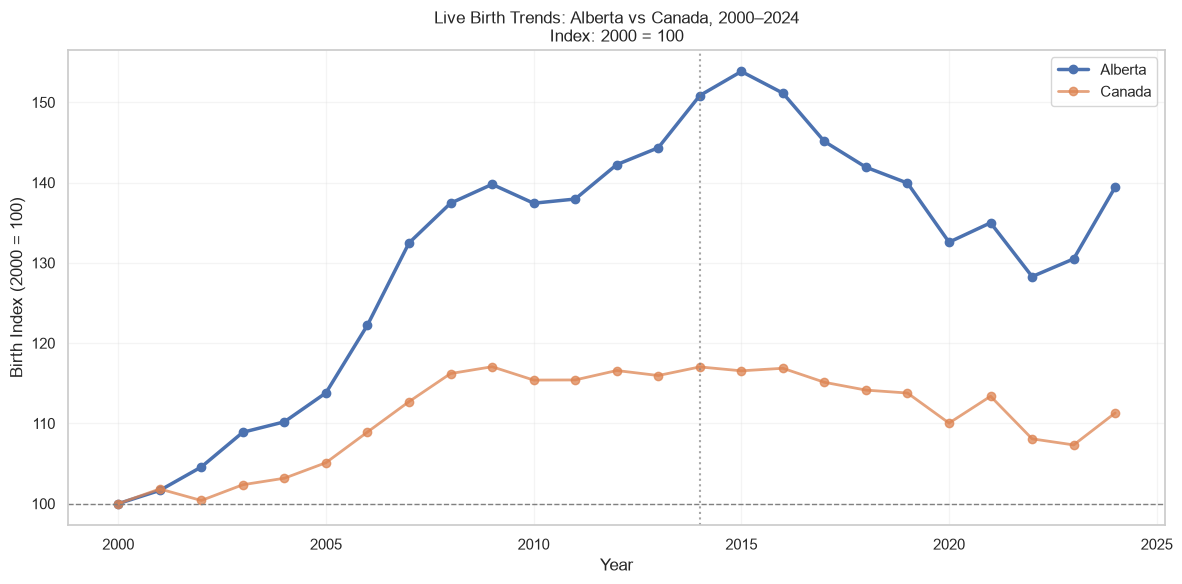

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    birth_trends["Year"],
    birth_trends["Alberta_Birth_Index"],
    marker="o",
    linewidth=2.5,
    label="Alberta"
)

plt.plot(
    birth_trends["Year"],
    birth_trends["Canada_Birth_Index"],
    marker="o",
    linewidth=2,
    alpha=0.75,
    label="Canada"
)

plt.axhline(
    100,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    2014,
    color="gray",
    linestyle=":",
    alpha=0.7
)

plt.title(
    "Live Birth Trends: Alberta vs Canada, 2000–2024\n"
    "Index: 2000 = 100"
)

plt.xlabel("Year")
plt.ylabel("Birth Index (2000 = 100)")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [89]:
# Approximate year each birth cohort reaches age 18

birth_trends["Approx_Age18_Year"] = birth_trends["Year"] + 18

cohort_pipeline = birth_trends[
    [
        "Year",
        "Approx_Age18_Year",
        "Alberta_Births",
        "Canada_Births"
    ]
].copy()

cohort_pipeline.tail(15)

,Year,Approx_Age18_Year,Alberta_Births,Canada_Births
10,2010,2028,50870,379191
11,2011,2029,51063,379244
12,2012,2030,52649,383101
13,2013,2031,53428,381054
14,2014,2032,55836,384577
15,2015,2033,56946,382979
16,2016,2034,55948,384023
17,2017,2035,53717,378280
18,2018,2036,52530,375086
19,2019,2037,51798,373889


In [90]:
future_pipeline = cohort_pipeline[
    cohort_pipeline["Approx_Age18_Year"].between(2024, 2042)
].copy()

future_pipelinefuture_pipeline = cohort_pipeline[
    cohort_pipeline["Approx_Age18_Year"].between(2024, 2042)
].copy()

future_pipeline

,Year,Approx_Age18_Year,Alberta_Births,Canada_Births
6,2006,2024,45250,357921
7,2007,2025,49039,370369
8,2008,2026,50871,381860
9,2009,2027,51741,384651
10,2010,2028,50870,379191
11,2011,2029,51063,379244
12,2012,2030,52649,383101
13,2013,2031,53428,381054
14,2014,2032,55836,384577
15,2015,2033,56946,382979


In [91]:
base_births = future_pipeline.loc[
    future_pipeline["Approx_Age18_Year"] == 2024,
    "Alberta_Births"
].iloc[0]

future_pipeline["Alberta_Age18_Pipeline_Index"] = (
    future_pipeline["Alberta_Births"] / base_births
) * 100

future_pipeline.round(2)

,Year,Approx_Age18_Year,Alberta_Births,Canada_Births,Alberta_Age18_Pipeline_Index
6,2006,2024,45250,357921,100.00
7,2007,2025,49039,370369,108.37
8,2008,2026,50871,381860,112.42
9,2009,2027,51741,384651,114.34
10,2010,2028,50870,379191,112.42
11,2011,2029,51063,379244,112.85
12,2012,2030,52649,383101,116.35
13,2013,2031,53428,381054,118.07
14,2014,2032,55836,384577,123.39
15,2015,2033,56946,382979,125.85


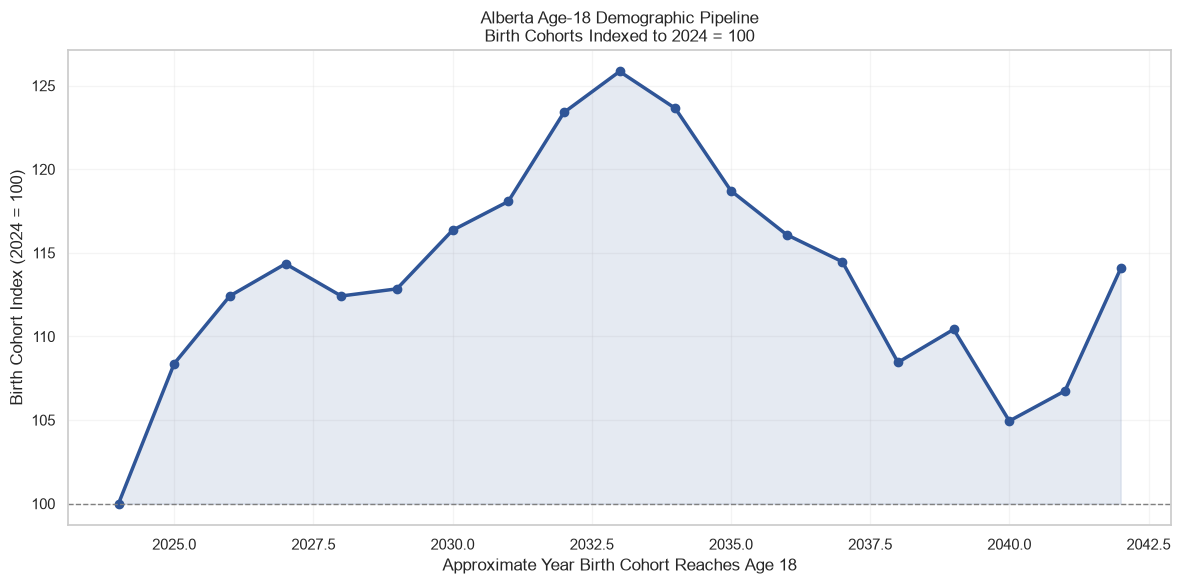

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    future_pipeline["Approx_Age18_Year"],
    future_pipeline["Alberta_Age18_Pipeline_Index"],
    marker="o",
    linewidth=2.5,
    color="#2F5597"
)

plt.axhline(
    100,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.fill_between(
    future_pipeline["Approx_Age18_Year"],
    100,
    future_pipeline["Alberta_Age18_Pipeline_Index"],
    alpha=0.12,
    color="#2F5597"
)

plt.title(
    "Alberta Age-18 Demographic Pipeline\n"
    "Birth Cohorts Indexed to 2024 = 100"
)

plt.xlabel("Approximate Year Birth Cohort Reaches Age 18")
plt.ylabel("Birth Cohort Index (2024 = 100)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [93]:
pipeline_checkpoints = future_pipeline[
    future_pipeline["Approx_Age18_Year"].isin(
        [2024, 2026, 2028, 2030, 2032, 2035, 2040, 2042]
    )
][
    [
        "Year",
        "Approx_Age18_Year",
        "Alberta_Births",
        "Alberta_Age18_Pipeline_Index"
    ]
]

pipeline_checkpoints.round(2)

,Year,Approx_Age18_Year,Alberta_Births,Alberta_Age18_Pipeline_Index
6,2006,2024,45250,100.00
8,2008,2026,50871,112.42
10,2010,2028,50870,112.42
12,2012,2030,52649,116.35
14,2014,2032,55836,123.39
17,2017,2035,53717,118.71
22,2022,2040,47487,104.94
24,2024,2042,51614,114.06


In [94]:
# Export demographic pipeline for Power BI

future_pipeline.to_csv(
    "../data/processed/alberta_age18_demographic_pipeline.csv",
    index=False
)

print("Saved:", future_pipeline.shape)
future_pipeline.head()

Saved: (19, 5)


,Year,Approx_Age18_Year,Alberta_Births,Canada_Births,Alberta_Age18_Pipeline_Index
6,2006,2024,45250,357921,100.00
7,2007,2025,49039,370369,108.37
8,2008,2026,50871,381860,112.42
9,2009,2027,51741,384651,114.34
10,2010,2028,50870,379191,112.42


In [95]:
international_context = pd.DataFrame({
    "Academic_Year": [
        "2019/2020",
        "2020/2021",
        "2021/2022",
        "2022/2023",
        "2023/2024",
        "2024/2025",
        "2025/2026"
    ],
    
    "College": [
        98247,
        85840,
        108619,
        146583,
        206013,
        200374,
        120130
    ],
    
    "University": [
        191012,
        191632,
        201026,
        208842,
        222064,
        210092,
        183616
    ],
    
    "Status": [
        "Observed",
        "Observed",
        "Observed",
        "Observed",
        "Observed",
        "Estimated",
        "Estimated"
    ]
})

international_context

,Academic_Year,College,University,Status
0,2019/2020,98247,191012,Observed
1,2020/2021,85840,191632,Observed
2,2021/2022,108619,201026,Observed
3,2022/2023,146583,208842,Observed
4,2023/2024,206013,222064,Observed
5,2024/2025,200374,210092,Estimated
6,2025/2026,120130,183616,Estimated


In [96]:
international_context["Total"] = (
    international_context["College"]
    + international_context["University"]
)

international_context

,Academic_Year,College,University,Status,Total
0,2019/2020,98247,191012,Observed,289259
1,2020/2021,85840,191632,Observed,277472
2,2021/2022,108619,201026,Observed,309645
3,2022/2023,146583,208842,Observed,355425
4,2023/2024,206013,222064,Observed,428077
5,2024/2025,200374,210092,Estimated,410466
6,2025/2026,120130,183616,Estimated,303746


In [97]:
international_context["Total_YoY_Pct"] = (
    international_context["Total"]
    .pct_change()
    .mul(100)
)

international_context.round(2)

,Academic_Year,College,University,Status,Total,Total_YoY_Pct
0,2019/2020,98247,191012,Observed,289259,NaN
1,2020/2021,85840,191632,Observed,277472,-4.07
2,2021/2022,108619,201026,Observed,309645,11.60
3,2022/2023,146583,208842,Observed,355425,14.78
4,2023/2024,206013,222064,Observed,428077,20.44
5,2024/2025,200374,210092,Estimated,410466,-4.11
6,2025/2026,120130,183616,Estimated,303746,-26.00


In [98]:
peak = international_context.loc[
    international_context["Total"].idxmax()
]

latest = international_context.iloc[-1]

change_peak_to_2025_26 = (
    (latest["Total"] - peak["Total"])
    / peak["Total"]
    * 100
)

print(
    f"Peak: {peak['Academic_Year']} = "
    f"{peak['Total']:,}"
)

print(
    f"2025/26 estimate = "
    f"{latest['Total']:,}"
)

print(
    f"Change from peak to 2025/26 = "
    f"{change_peak_to_2025_26:.2f}%"
)

Peak: 2023/2024 = 428,077
2025/26 estimate = 303,746
Change from peak to 2025/26 = -29.04%


In [99]:
# Source:
# Statistics Canada, "International students in public postsecondary institutions"
# Chart 1 – Number of full-time international students in public postsecondary
# institutions by institution type, observed (2019/2020 to 2023/2024)
# and estimated (2024/2025 and 2025/2026).
#
# https://www150.statcan.gc.ca/n1/daily-quotidien/260505/cg-b001-eng.htm
#
# Observed values originate from the Postsecondary Student Information System (PSIS).
# 2024/2025 and 2025/2026 values are Statistics Canada estimates.

In [100]:
international_context.to_csv(
    "../data/processed/canada_international_student_context.csv",
    index=False
)

In [101]:
peak_row = international_context[
    international_context["Academic_Year"] == "2023/2024"
].iloc[0]

forecast_row = international_context[
    international_context["Academic_Year"] == "2025/2026"
].iloc[0]

college_abs_change = (
    forecast_row["College"] - peak_row["College"]
)

university_abs_change = (
    forecast_row["University"] - peak_row["University"]
)

college_change_pct = (
    college_abs_change / peak_row["College"] * 100
)

university_change_pct = (
    university_abs_change / peak_row["University"] * 100
)

print(
    f"College: {peak_row['College']:,} -> "
    f"{forecast_row['College']:,} | "
    f"{college_abs_change:,} ({college_change_pct:.2f}%)"
)

print(
    f"University: {peak_row['University']:,} -> "
    f"{forecast_row['University']:,} | "
    f"{university_abs_change:,} ({university_change_pct:.2f}%)"
)

College: 206,013 -> 120,130 | -85,883 (-41.69%)
University: 222,064 -> 183,616 | -38,448 (-17.31%)


In [102]:
international_context["Geography"] = "Canada"

international_context["Source"] = (
    "Statistics Canada - Postsecondary Student Information System (PSIS)"
)

international_context["Source_URL"] = (
    "https://www150.statcan.gc.ca/n1/daily-quotidien/260505/cg-b001-eng.htm"
)

international_context

,Academic_Year,College,University,Status,Total,Total_YoY_Pct,Geography,Source,Source_URL
0,2019/2020,98247,191012,Observed,289259,NaN,Canada,Statistics Canada - Postsecondary Student Info...,https://www150.statcan.gc.ca/n1/daily-quotidie...
1,2020/2021,85840,191632,Observed,277472,-4.07,Canada,Statistics Canada - Postsecondary Student Info...,https://www150.statcan.gc.ca/n1/daily-quotidie...
2,2021/2022,108619,201026,Observed,309645,11.60,Canada,Statistics Canada - Postsecondary Student Info...,https://www150.statcan.gc.ca/n1/daily-quotidie...
3,2022/2023,146583,208842,Observed,355425,14.78,Canada,Statistics Canada - Postsecondary Student Info...,https://www150.statcan.gc.ca/n1/daily-quotidie...
4,2023/2024,206013,222064,Observed,428077,20.44,Canada,Statistics Canada - Postsecondary Student Info...,https://www150.statcan.gc.ca/n1/daily-quotidie...
5,2024/2025,200374,210092,Estimated,410466,-4.11,Canada,Statistics Canada - Postsecondary Student Info...,https://www150.statcan.gc.ca/n1/daily-quotidie...
6,2025/2026,120130,183616,Estimated,303746,-26.00,Canada,Statistics Canada - Postsecondary Student Info...,https://www150.statcan.gc.ca/n1/daily-quotidie...


In [103]:
international_context.to_csv(
    "../data/processed/canada_international_student_context.csv",
    index=False
)

print("Exported successfully.")
print(international_context.shape)
print(international_context.columns.tolist())

Exported successfully.
(7, 9)
['Academic_Year', 'College', 'University', 'Status', 'Total', 'Total_YoY_Pct', 'Geography', 'Source', 'Source_URL']


### International Student Context

International student enrolment increased substantially through 2023/24,
reaching 428,077 students across colleges and universities in this analysis.

The 2024/25 and 2025/26 values are estimates rather than observed enrolment.
Under this scenario, total international enrolment falls to approximately
303,746 by 2025/26, about 29% below the 2023/24 peak.

The estimated decline is substantially larger for colleges (-41.7%) than
universities (-17.3%), suggesting that policy-driven changes to international
student flows may affect different parts of Canada's post-secondary system
unevenly.

These figures are used as external context and are not treated as a direct
forecast of Alberta post-secondary enrolment.

In [104]:
# Check the enrolment datasets currently available in memory

for name in [
    "enrolment",
    "enrolment_clean",
    "alberta_enrolment",
    "combined_enrolment",
    "df"
]:
    if name in globals():
        obj = globals()[name]
        print(f"\n{name}:")
        print("Shape:", obj.shape)
        print("Columns:", obj.columns.tolist())

In [105]:
# Show DataFrames currently loaded in the notebook

import pandas as pd

for name, obj in globals().copy().items():
    if isinstance(obj, pd.DataFrame):
        print(f"{name}: {obj.shape}")
        print(obj.columns.tolist())
        print("-" * 70)

_: (7, 9)
['Academic_Year', 'College', 'University', 'Status', 'Total', 'Total_YoY_Pct', 'Geography', 'Source', 'Source_URL']
----------------------------------------------------------------------
__: (7, 6)
['Academic_Year', 'College', 'University', 'Status', 'Total', 'Total_YoY_Pct']
----------------------------------------------------------------------
___: (7, 9)
['Academic_Year', 'College', 'University', 'Status', 'Total', 'Total_YoY_Pct', 'Geography', 'Source', 'Source_URL']
----------------------------------------------------------------------
dataset1: (260, 7)
['Province', 'Institution', 'Record_Type', 'Academic_Year', 'Academic_Year_Start', 'Academic_Year_End', 'Enrolment']
----------------------------------------------------------------------
dataset2: (780, 10)
['Institution_Raw', 'Institution', 'Institution_Standardized', 'Academic_Year', 'Enrolment', 'Student_Status', 'Province', 'Record_Type', 'Academic_Year_Start', 'Academic_Year_End']
----------------------------------

In [106]:
provincial[
    [
        "Academic_Year",
        "Academic_Year_Start",
        "Academic_Year_End",
        "Enrolment",
        "Canadian",
        "International"
    ]
].sort_values("Academic_Year_Start")

,Academic_Year,Academic_Year_Start,Academic_Year_End,Enrolment,Canadian,International
0,2014/2015,2014,2015,184026,"167,463.00","16,458.00"
1,2015/2016,2015,2016,185679,"167,946.00","17,478.00"
2,2016/2017,2016,2017,190947,"172,506.00","18,303.00"
3,2017/2018,2017,2018,194010,"175,065.00","18,798.00"
4,2018/2019,2018,2019,200391,"178,617.00","21,663.00"
5,2019/2020,2019,2020,203823,"179,178.00","24,636.00"
6,2020/2021,2020,2021,203523,"179,850.00","23,667.00"
7,2021/2022,2021,2022,203580,"178,239.00","25,311.00"
8,2022/2023,2022,2023,205734,"175,698.00","30,018.00"
9,2023/2024,2023,2024,216957,"179,535.00","37,416.00"


## Demographic Pipeline vs. Alberta Postsecondary Enrolment

This analysis compares Alberta postsecondary enrolment with the approximate
size of Alberta birth cohorts reaching age 18.

Academic year start is used as the reference year for matching enrolment to
the demographic pipeline. The relationship is contextual rather than a
one-to-one cohort match, since postsecondary students include individuals
of different ages, international students, migrants, and returning learners.

In [107]:
# Prepare Alberta enrolment data for demographic comparison

enrolment_demo = provincial[
    [
        "Academic_Year",
        "Academic_Year_Start",
        "Enrolment",
        "Canadian",
        "International"
    ]
].copy()

enrolment_demo = enrolment_demo.rename(
    columns={"Academic_Year_Start": "Approx_Age18_Year"}
)

# Prepare demographic pipeline
demo_pipeline = cohort_pipeline[
    [
        "Approx_Age18_Year",
        "Alberta_Births"
    ]
].copy()

# Merge enrolment with approximate age-18 birth cohort
demo_enrolment = enrolment_demo.merge(
    demo_pipeline,
    on="Approx_Age18_Year",
    how="left"
)

demo_enrolment

,Academic_Year,Approx_Age18_Year,Enrolment,Canadian,International,Alberta_Births
0,2014/2015,2014,184026,"167,463.00","16,458.00",NaN
1,2015/2016,2015,185679,"167,946.00","17,478.00",NaN
2,2016/2017,2016,190947,"172,506.00","18,303.00",NaN
3,2017/2018,2017,194010,"175,065.00","18,798.00",NaN
4,2018/2019,2018,200391,"178,617.00","21,663.00","37,015.00"
5,2019/2020,2019,203823,"179,178.00","24,636.00","37,626.00"
6,2020/2021,2020,203523,"179,850.00","23,667.00","38,707.00"
7,2021/2022,2021,203580,"178,239.00","25,311.00","40,308.00"
8,2022/2023,2022,205734,"175,698.00","30,018.00","40,789.00"
9,2023/2024,2023,216957,"179,535.00","37,416.00","42,124.00"


In [108]:
print("Rows:", len(demo_enrolment))
print("Missing demographic matches:",
      demo_enrolment["Alberta_Births"].isna().sum())

demo_enrolment[
    [
        "Academic_Year",
        "Approx_Age18_Year",
        "Enrolment",
        "Canadian",
        "International",
        "Alberta_Births"
    ]
]

Rows: 10
Missing demographic matches: 4


,Academic_Year,Approx_Age18_Year,Enrolment,Canadian,International,Alberta_Births
0,2014/2015,2014,184026,"167,463.00","16,458.00",NaN
1,2015/2016,2015,185679,"167,946.00","17,478.00",NaN
2,2016/2017,2016,190947,"172,506.00","18,303.00",NaN
3,2017/2018,2017,194010,"175,065.00","18,798.00",NaN
4,2018/2019,2018,200391,"178,617.00","21,663.00","37,015.00"
5,2019/2020,2019,203823,"179,178.00","24,636.00","37,626.00"
6,2020/2021,2020,203523,"179,850.00","23,667.00","38,707.00"
7,2021/2022,2021,203580,"178,239.00","25,311.00","40,308.00"
8,2022/2023,2022,205734,"175,698.00","30,018.00","40,789.00"
9,2023/2024,2023,216957,"179,535.00","37,416.00","42,124.00"


In [109]:
# Keep only years where demographic cohort data are available

demo_enrolment_matched = (
    demo_enrolment
    .dropna(subset=["Alberta_Births"])
    .copy()
)

demo_enrolment_matched["Alberta_Births"] = (
    demo_enrolment_matched["Alberta_Births"].astype(int)
)

print("Matched observations:", len(demo_enrolment_matched))

demo_enrolment_matched

Matched observations: 6


,Academic_Year,Approx_Age18_Year,Enrolment,Canadian,International,Alberta_Births
4,2018/2019,2018,200391,"178,617.00","21,663.00",37015
5,2019/2020,2019,203823,"179,178.00","24,636.00",37626
6,2020/2021,2020,203523,"179,850.00","23,667.00",38707
7,2021/2022,2021,203580,"178,239.00","25,311.00",40308
8,2022/2023,2022,205734,"175,698.00","30,018.00",40789
9,2023/2024,2023,216957,"179,535.00","37,416.00",42124


In [110]:
# Index each series to the first matched year = 100

base = demo_enrolment_matched.iloc[0]

demo_enrolment_matched["Birth_Cohort_Index"] = (
    demo_enrolment_matched["Alberta_Births"]
    / base["Alberta_Births"] * 100
)

demo_enrolment_matched["Total_Enrolment_Index"] = (
    demo_enrolment_matched["Enrolment"]
    / base["Enrolment"] * 100
)

demo_enrolment_matched["Canadian_Enrolment_Index"] = (
    demo_enrolment_matched["Canadian"]
    / base["Canadian"] * 100
)

demo_enrolment_matched["International_Enrolment_Index"] = (
    demo_enrolment_matched["International"]
    / base["International"] * 100
)

demo_enrolment_matched[
    [
        "Academic_Year",
        "Birth_Cohort_Index",
        "Total_Enrolment_Index",
        "Canadian_Enrolment_Index",
        "International_Enrolment_Index"
    ]
].round(2)

,Academic_Year,Birth_Cohort_Index,Total_Enrolment_Index,Canadian_Enrolment_Index,International_Enrolment_Index
4,2018/2019,100.00,100.00,100.00,100.00
5,2019/2020,101.65,101.71,100.31,113.72
6,2020/2021,104.57,101.56,100.69,109.25
7,2021/2022,108.90,101.59,99.79,116.84
8,2022/2023,110.20,102.67,98.37,138.57
9,2023/2024,113.80,108.27,100.51,172.72


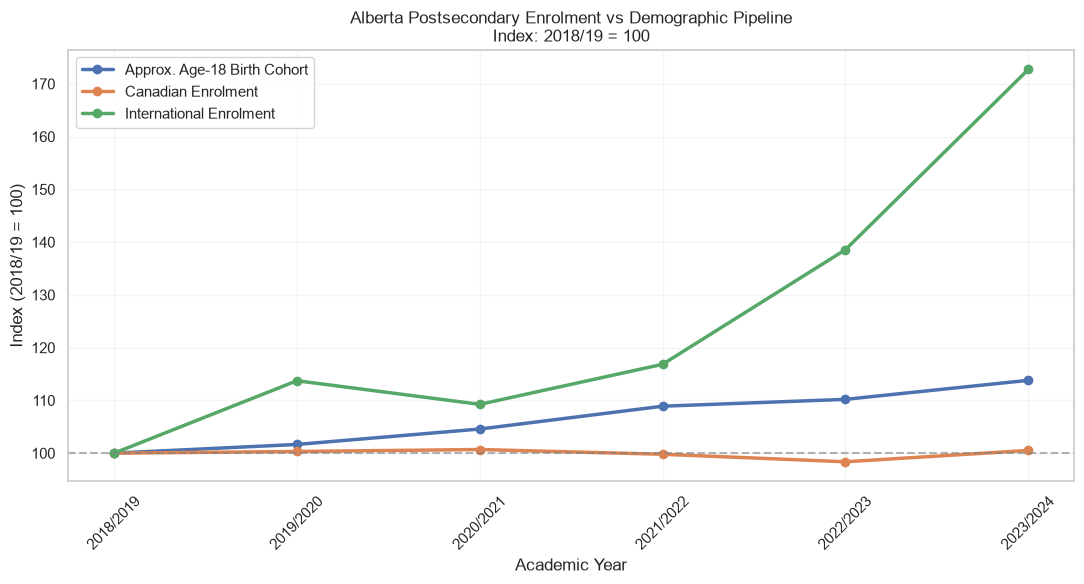

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.plot(
    demo_enrolment_matched["Academic_Year"],
    demo_enrolment_matched["Birth_Cohort_Index"],
    marker="o",
    linewidth=2.5,
    label="Approx. Age-18 Birth Cohort"
)

plt.plot(
    demo_enrolment_matched["Academic_Year"],
    demo_enrolment_matched["Canadian_Enrolment_Index"],
    marker="o",
    linewidth=2.5,
    label="Canadian Enrolment"
)

plt.plot(
    demo_enrolment_matched["Academic_Year"],
    demo_enrolment_matched["International_Enrolment_Index"],
    marker="o",
    linewidth=2.5,
    label="International Enrolment"
)

plt.axhline(100, color="gray", linestyle="--", alpha=0.6)

plt.title(
    "Alberta Postsecondary Enrolment vs Demographic Pipeline\n"
    "Index: 2018/19 = 100"
)
plt.ylabel("Index (2018/19 = 100)")
plt.xlabel("Academic Year")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

### Demographic Pipeline vs Enrolment

From 2018/19 to 2023/24, Alberta's approximate age-18 birth cohort increased by 13.8%, while Canadian postsecondary enrolment remained relatively stable (+0.5%). Over the same period, international enrolment increased by 72.7%, contributing substantially to overall enrolment growth of 8.3%.

The divergence suggests that recent enrolment growth was much more closely associated with international student growth than with growth in the traditional-age demographic pipeline.

The birth-cohort series should be interpreted as a demographic indicator rather than a direct measure of postsecondary demand. Enrolment is also influenced by participation rates, migration, student mobility, institutional capacity, economic conditions, and policy changes.

In [112]:
start = demo_enrolment_matched.iloc[0]
end = demo_enrolment_matched.iloc[-1]

total_growth = end["Enrolment"] - start["Enrolment"]
canadian_growth = end["Canadian"] - start["Canadian"]
international_growth = end["International"] - start["International"]

international_share_growth = (
    international_growth / total_growth * 100
)

print(f"Total enrolment growth: {total_growth:,.0f}")
print(f"Canadian enrolment growth: {canadian_growth:,.0f}")
print(f"International enrolment growth: {international_growth:,.0f}")
print(
    f"International contribution to net growth: "
    f"{international_share_growth:.1f}%"
)

Total enrolment growth: 16,566
Canadian enrolment growth: 918
International enrolment growth: 15,753
International contribution to net growth: 95.1%


### Key Finding: Source of Enrolment Growth

Between 2018/19 and 2023/24, total postsecondary enrolment increased by 16,566 students. Over the same period, international enrolment increased by 15,753 students, equivalent to approximately 95.1% of the net increase in total enrolment.

Canadian enrolment increased by only 918 students during the period. This indicates that recent overall enrolment growth was associated primarily with expansion in international enrolment rather than comparable growth in Canadian enrolment.

Combined with the demographic analysis, this shows an important divergence: Alberta's approximate traditional-age demographic pipeline increased by 13.8%, while Canadian enrolment remained nearly flat (+0.5%).

In [113]:
# Export demographic vs enrolment analytical dataset

powerbi_demo = demo_enrolment_matched[
    [
        "Academic_Year",
        "Approx_Age18_Year",
        "Enrolment",
        "Canadian",
        "International",
        "Alberta_Births",
        "Birth_Cohort_Index",
        "Canadian_Enrolment_Index",
        "International_Enrolment_Index"
    ]
].copy()

powerbi_demo.to_csv(
    "../data/processed/powerbi_demographic_enrolment.csv",
    index=False
)

print("Exported:", powerbi_demo.shape)
print(powerbi_demo.columns.tolist())

powerbi_demo

Exported: (6, 9)
['Academic_Year', 'Approx_Age18_Year', 'Enrolment', 'Canadian', 'International', 'Alberta_Births', 'Birth_Cohort_Index', 'Canadian_Enrolment_Index', 'International_Enrolment_Index']


,Academic_Year,Approx_Age18_Year,Enrolment,Canadian,International,Alberta_Births,Birth_Cohort_Index,Canadian_Enrolment_Index,International_Enrolment_Index
4,2018/2019,2018,200391,"178,617.00","21,663.00",37015,100.00,100.00,100.00
5,2019/2020,2019,203823,"179,178.00","24,636.00",37626,101.65,100.31,113.72
6,2020/2021,2020,203523,"179,850.00","23,667.00",38707,104.57,100.69,109.25
7,2021/2022,2021,203580,"178,239.00","25,311.00",40308,108.90,99.79,116.84
8,2022/2023,2022,205734,"175,698.00","30,018.00",40789,110.20,98.37,138.57
9,2023/2024,2023,216957,"179,535.00","37,416.00",42124,113.80,100.51,172.72


In [114]:
powerbi_demo = demo_enrolment_matched[
    [
        "Academic_Year",
        "Approx_Age18_Year",
        "Enrolment",
        "Canadian",
        "International",
        "Alberta_Births",
        "Birth_Cohort_Index",
        "Canadian_Enrolment_Index",
        "International_Enrolment_Index"
    ]
].copy()

powerbi_demo.to_csv(
    "../data/processed/powerbi_demographic_enrolment.csv",
    index=False
)

print("Exported:", powerbi_demo.shape)
print(powerbi_demo.columns.tolist())

Exported: (6, 9)
['Academic_Year', 'Approx_Age18_Year', 'Enrolment', 'Canadian', 'International', 'Alberta_Births', 'Birth_Cohort_Index', 'Canadian_Enrolment_Index', 'International_Enrolment_Index']


In [115]:
birth_trends.to_csv(
    "../data/processed/powerbi_birth_trends.csv",
    index=False
)

print("Birth trends exported:", birth_trends.shape)
print(birth_trends.columns.tolist())

Birth trends exported: (25, 6)
['Year', 'Canada_Births', 'Alberta_Births', 'Canada_Birth_Index', 'Alberta_Birth_Index', 'Approx_Age18_Year']


In [116]:
future_pipeline.to_csv(
    "../data/processed/powerbi_age18_pipeline.csv",
    index=False
)

print("Age-18 pipeline exported:", future_pipeline.shape)
print(future_pipeline.columns.tolist())

Age-18 pipeline exported: (19, 5)
['Year', 'Approx_Age18_Year', 'Alberta_Births', 'Canada_Births', 'Alberta_Age18_Pipeline_Index']


In [117]:
import os

processed_path = "../data/processed"

for file in sorted(os.listdir(processed_path)):
    print(file)

alberta_age18_demographic_pipeline.csv
alberta_enrolment_2014_2024_clean.csv
alberta_postsecondary_master.csv
alberta_student_status_clean.csv
canada_international_student_context.csv
powerbi_age18_pipeline.csv
powerbi_birth_trends.csv
powerbi_demographic_enrolment.csv


In [118]:
import pandas as pd
import os

processed_path = "../data/processed"

files = [
    "alberta_postsecondary_master.csv",
    "alberta_enrolment_2014_2024_clean.csv",
    "alberta_student_status_clean.csv",
    "canada_international_student_context.csv",
    "powerbi_age18_pipeline.csv",
    "powerbi_birth_trends.csv",
    "powerbi_demographic_enrolment.csv"
]

for file in files:
    path = os.path.join(processed_path, file)
    df = pd.read_csv(path)

    print("=" * 70)
    print(file)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:", df.isna().sum().sum())
    print("Columns:", df.columns.tolist())

alberta_postsecondary_master.csv
Rows: 260
Columns: 12
Duplicate rows: 0
Missing values: 0
Columns: ['Province', 'Institution', 'Record_Type', 'Academic_Year', 'Academic_Year_Start', 'Academic_Year_End', 'Enrolment', 'Canadian', 'International', 'International_Share_Pct', 'Canadian_Share_Pct', 'Status_Sum_Difference']
alberta_enrolment_2014_2024_clean.csv
Rows: 260
Columns: 7
Duplicate rows: 0
Missing values: 0
Columns: ['Province', 'Institution', 'Record_Type', 'Academic_Year', 'Academic_Year_Start', 'Academic_Year_End', 'Enrolment']
alberta_student_status_clean.csv
Rows: 780
Columns: 10
Duplicate rows: 0
Missing values: 0
Columns: ['Institution_Raw', 'Institution', 'Institution_Standardized', 'Academic_Year', 'Enrolment', 'Student_Status', 'Province', 'Record_Type', 'Academic_Year_Start', 'Academic_Year_End']
canada_international_student_context.csv
Rows: 7
Columns: 9
Duplicate rows: 0
Missing values: 1
Columns: ['Academic_Year', 'College', 'University', 'Status', 'Total', 'Total_YoY